In [1]:
%load_ext watermark


In [2]:
import os
import subprocess

os.environ["POLARS_FORCE_NEW_STREAMING"] = "1"

from IPython.display import display, HTML
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
from teeplot import teeplot as tp
from tqdm import tqdm

from pylib._calc_compsummary_stats import calc_compsummary_stats
from pylib._seed_global_rngs import seed_global_rngs


Covasim 3.1.6 (2024-01-28) — © 2020-2024 by IDM


In [3]:
%watermark -diwmuv -iv


Last updated: 2025-05-21T22:43:01.282876+00:00

Python implementation: CPython
Python version       : 3.10.12
IPython version      : 7.31.1

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.8.0-1027-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit

polars : 1.29.0
teeplot: 1.4.2
seaborn: 0.13.2
pandas : 2.2.3
numpy  : 2.1.2

Watermark: 2.4.3



In [4]:
teeplot_subdir = "2025-05-19-compscreen-multistrain-summary"
teeplot_subdir


'2025-05-19-compscreen-multistrain-summary'

In [5]:
seed_global_rngs(1)


## Get Data


In [6]:
data_sources = {
    # "uk": "https://osf.io/mkjy5/download",
    "multistrain": "https://osf.io/ywmpt/download",
    # "vanilla": "https://osf.io/r8skg/download",
    # "vanilla-big": "https://osf.io/j4795/download",
    # "vanilla-big-1.3x": "https://osf.io/cnp5z/download",
}
tmp_path = f"/tmp/{teeplot_subdir}.pqt"


In [7]:
results = []

for source_name, url in data_sources.items():
    print(f"Downloading {source_name} data from {url}")

    subprocess.run(
        [
            "wget",
            "--tries=5",
            "--show-progress",
            "--progress=bar:force",
            "-O",
            str(tmp_path),
            url,
        ],
        check=True,
    )

    df = pl.scan_parquet(
        tmp_path,
        low_memory=True,
        retries=5,
    )

    unique_groups = (
        df.unique(
            [
                "trt_name",
                "trt_n_downsample",
                "trt_hsurf_bits",
                "replicate_uuid",
            ]
        )
        .select(
            pl.col("trt_name"),
            pl.col("trt_n_downsample"),
            pl.col("trt_hsurf_bits"),
            pl.col("replicate_uuid"),
        )
        .drop_nans()
        .drop_nulls()
        .collect(engine="streaming")
    )

    for (trt_name, trt_n_downsample, trt_hsurf_bits, replicate_uuid) in tqdm(
        [*unique_groups.iter_rows()],
    ):
        group = df.filter(
            (pl.col("trt_name") == trt_name)
            & (pl.col("trt_n_downsample") == trt_n_downsample)
            & (pl.col("trt_hsurf_bits") == trt_hsurf_bits)
            & (pl.col("replicate_uuid") == replicate_uuid)
        ).collect(engine="streaming")

        for y in (
            "defmut_norm_all-num_leaves",
            # "defmut_norm_ot_bin:week-num_leaves",
            # "defmut_norm_ot_bin:fortnight-num_leaves",
            "defmut_norm_ot_bin:month-num_leaves",
            # "defmut_norm_ot_bin:quarter-num_leaves",
            # "defmut_norm_ot_bin:year-num_leaves",
            "defmut_norm_match:variant_flavor-num_leaves",
            "defmut_norm_ot_bin:month&match:variant_flavor-num_leaves",
            "defmut_norm_all-clade_duration",
            # "defmut_norm_ot_bin:week-clade_duration",
            # "defmut_norm_ot_bin:fortnight-clade_duration",
            "defmut_norm_ot_bin:month-clade_duration",
            # "defmut_norm_ot_bin:quarter-clade_duration",
            # "defmut_norm_ot_bin:year-clade_duration",
            "defmut_norm_match:variant_flavor-clade_duration",
            "defmut_norm_ot_bin:month&match:variant_flavor-clade_duration",
        ):
            res = calc_compsummary_stats(
                group.to_pandas(),
                x="is_focal_defmut",
                y=y,
            )
            results.extend(
                {
                    "source_name": source_name,
                    "trt_name": trt_name,
                    "trt_n_downsample": trt_n_downsample,
                    "trt_hsurf_bits": trt_hsurf_bits,
                    "replicate_uuid": replicate_uuid,
                    "y": y,
                    **record,
                }
                for record in res
            )


--2025-05-21 22:43:01--  https://osf.io/ywmpt/download
Resolving osf.io (osf.io)... 35.190.84.173
Connecting to osf.io (osf.io)|35.190.84.173|:443... connected.
HTTP request sent, awaiting response... 302 FOUND
Location: https://files.osf.io/v1/resources/37fv8/providers/osfstorage/682cae3abb3f815770b06cc8?action=download&direct&version=2 [following]
--2025-05-21 22:43:01--  https://files.osf.io/v1/resources/37fv8/providers/osfstorage/682cae3abb3f815770b06cc8?action=download&direct&version=2
Resolving files.osf.io (files.osf.io)... 35.186.214.196
Connecting to files.osf.io (files.osf.io)|35.186.214.196|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1164969026 (1.1G) [application/octet-stream]
Saving to: ‘/tmp/2025-05-19-compscreen-multistrain-summary.pqt’

/tmp/2025-05-19-com 100%[===================>]   1.08G  27.8MB/s    in 66s     

2025-05-21 22:44:11 (16.9 MB/s) - ‘/tmp/2025-05-19-compscreen-multistrain-summary.pqt’ saved [1164969026/1164969026]

100%|███

In [8]:
results_df = pd.DataFrame(results)
results_df


,source_name,trt_name,trt_n_downsample,trt_hsurf_bits,replicate_uuid,y,label,binom_n,binom_k,n,n_boot,p_boot,p_binom,p_mw,u_mw,cliffs_delta,na
0,multistrain,Sneu/Gneu,1000000,0,5cb2645f-38f3-8478-a5ea-bfc9d9108460,defmut_norm_all-num_leaves,all,4679,2772,4679,10000,0.5113,0.506300,NaN,NaN,NaN,0
1,multistrain,Sneu/Gneu,1000000,0,5cb2645f-38f3-8478-a5ea-bfc9d9108460,defmut_norm_all-num_leaves,False,4663,2764,4679,10000,0.4882,0.488729,0.722684,34471.0,-0.075944,0
2,multistrain,Sneu/Gneu,1000000,0,5cb2645f-38f3-8478-a5ea-bfc9d9108460,defmut_norm_all-num_leaves,True,16,8,4679,10000,0.7257,0.842989,0.277385,40137.0,0.075944,0
3,multistrain,Sneu/Gneu,1000000,0,5cb2645f-38f3-8478-a5ea-bfc9d9108460,defmut_norm_ot_bin:month-num_leaves,all,4679,2779,4679,10000,0.4973,0.506309,NaN,NaN,NaN,0
4,multistrain,Sneu/Gneu,1000000,0,5cb2645f-38f3-8478-a5ea-bfc9d9108460,defmut_norm_ot_bin:month-num_leaves,False,4663,2771,4679,10000,0.4841,0.488443,0.685531,34699.0,-0.069832,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
811,multistrain,Sben1.1x/Gneu,1000000,0,c65dc6a9-3280-83b1-bb63-aa4c4ed25f26,defmut_norm_match:variant_flavor-clade_duration,False,4719,2753,4748,10000,0.4543,0.483764,0.949383,56475.5,-0.174642,0
812,multistrain,Sben1.1x/Gneu,1000000,0,c65dc6a9-3280-83b1-bb63-aa4c4ed25f26,defmut_norm_match:variant_flavor-clade_duration,True,29,15,4748,10000,0.8403,0.818009,0.050631,80375.5,0.174642,0
813,multistrain,Sben1.1x/Gneu,1000000,0,c65dc6a9-3280-83b1-bb63-aa4c4ed25f26,defmut_norm_ot_bin:month&match:variant_flavor-...,all,4748,2777,4748,10000,0.5033,0.533684,NaN,NaN,NaN,0
814,multistrain,Sben1.1x/Gneu,1000000,0,c65dc6a9-3280-83b1-bb63-aa4c4ed25f26,defmut_norm_ot_bin:month&match:variant_flavor-...,False,4719,2762,4748,10000,0.4551,0.510539,0.920031,58087.5,-0.151084,0


In [9]:
results_df["y"] = results_df["y"].str.removeprefix("defmut_norm_all-")
results_df["y"] = results_df["y"].str.removeprefix("defmut_norm_ot_bin:")
results_df["y"] = results_df["y"].str.removeprefix("defmut_norm_match:")
results_df["y"] = results_df["y"].str.replace("-", "\n")
results_df["y"] = results_df["y"].str.replace("_", " ")

results_df["label"] = results_df["label"].astype(str)
results_df["label"] = results_df["label"].str.replace("False", "bkgnd")
results_df["label"] = results_df["label"].str.replace("True", "focal")

results_df["trt_name_"] = results_df["trt_name"].str.replace("/", "\n")


teeplots/2025-05-19-compscreen-multistrain-summary/col=trt-name+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=p-boot+ext=.pdf
teeplots/2025-05-19-compscreen-multistrain-summary/col=trt-name+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=p-boot+ext=.png


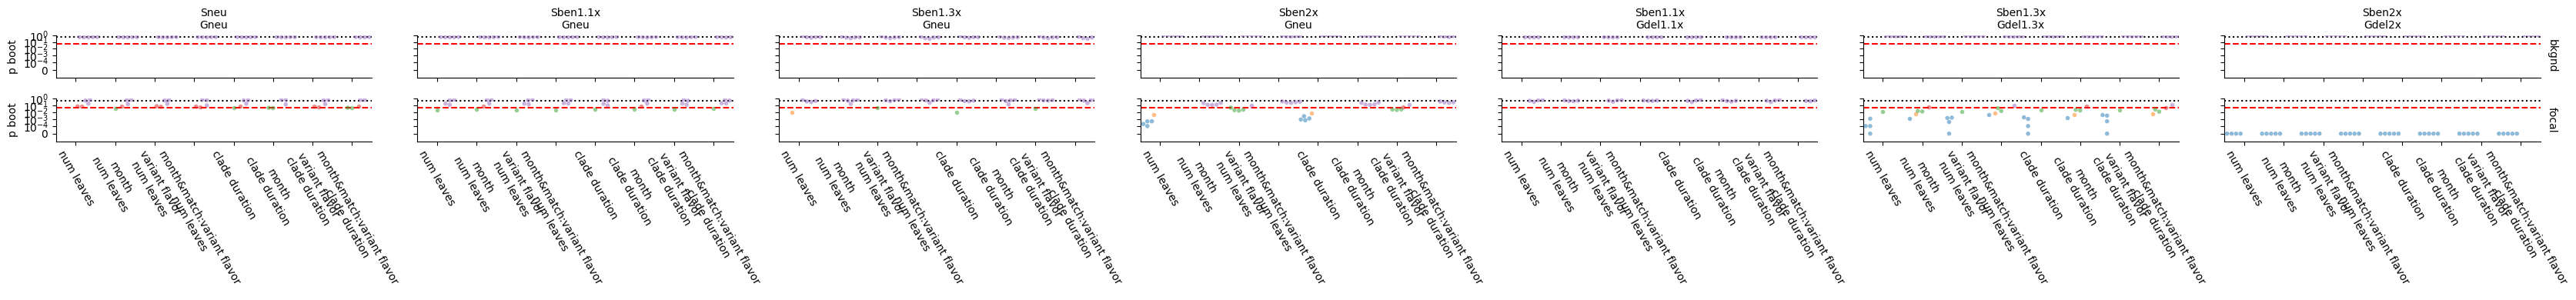

teeplots/2025-05-19-compscreen-multistrain-summary/col=trt-name+comparator=month+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=p-boot+ext=.pdf
teeplots/2025-05-19-compscreen-multistrain-summary/col=trt-name+comparator=month+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=p-boot+ext=.png


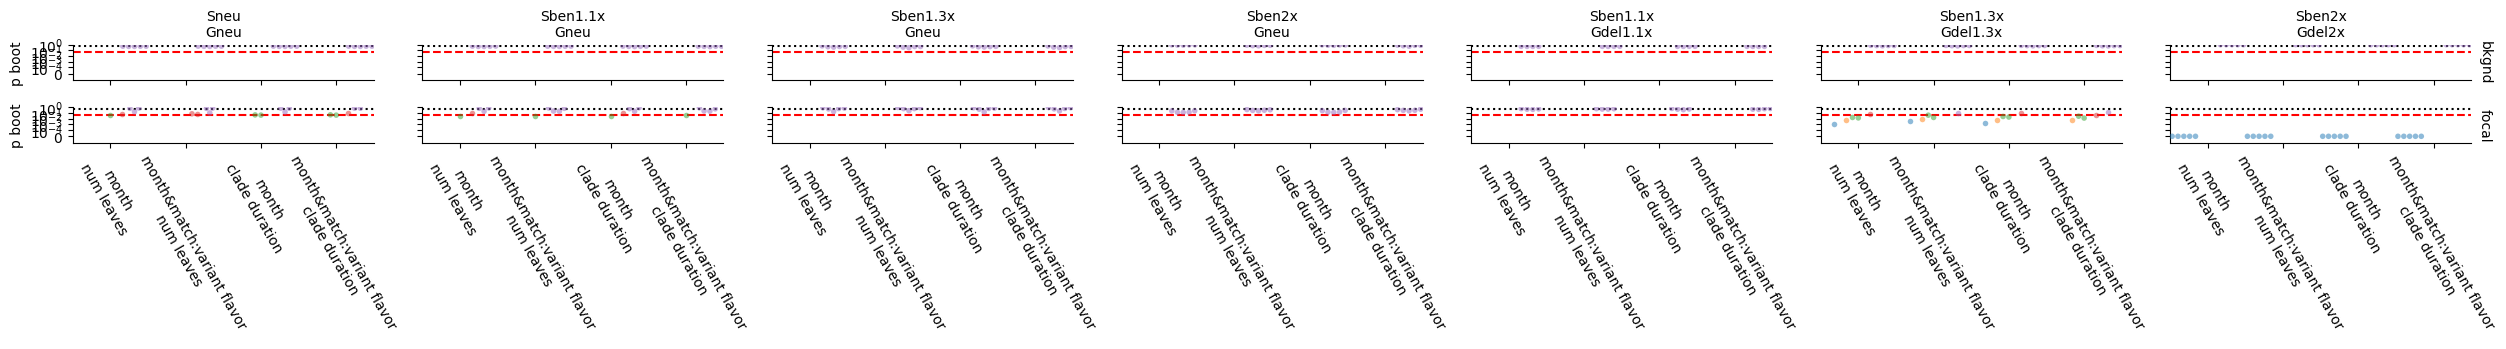

teeplots/2025-05-19-compscreen-multistrain-summary/col=trt-name+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=p-binom+ext=.pdf
teeplots/2025-05-19-compscreen-multistrain-summary/col=trt-name+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=p-binom+ext=.png


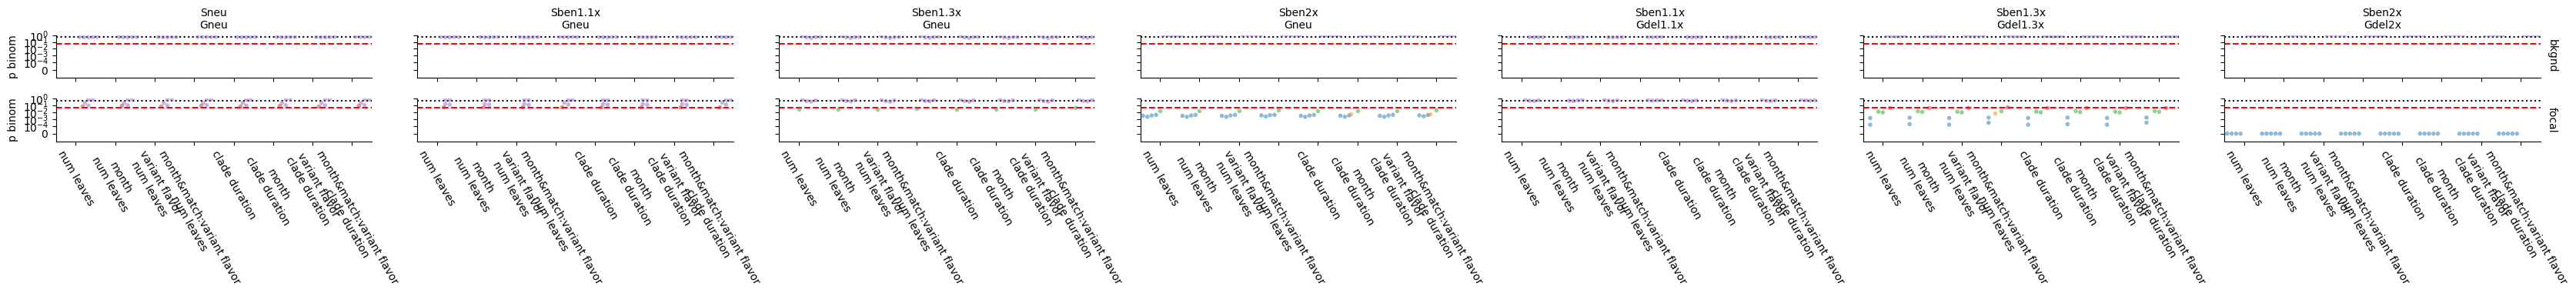

teeplots/2025-05-19-compscreen-multistrain-summary/col=trt-name+comparator=month+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=p-binom+ext=.pdf
teeplots/2025-05-19-compscreen-multistrain-summary/col=trt-name+comparator=month+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=p-binom+ext=.png


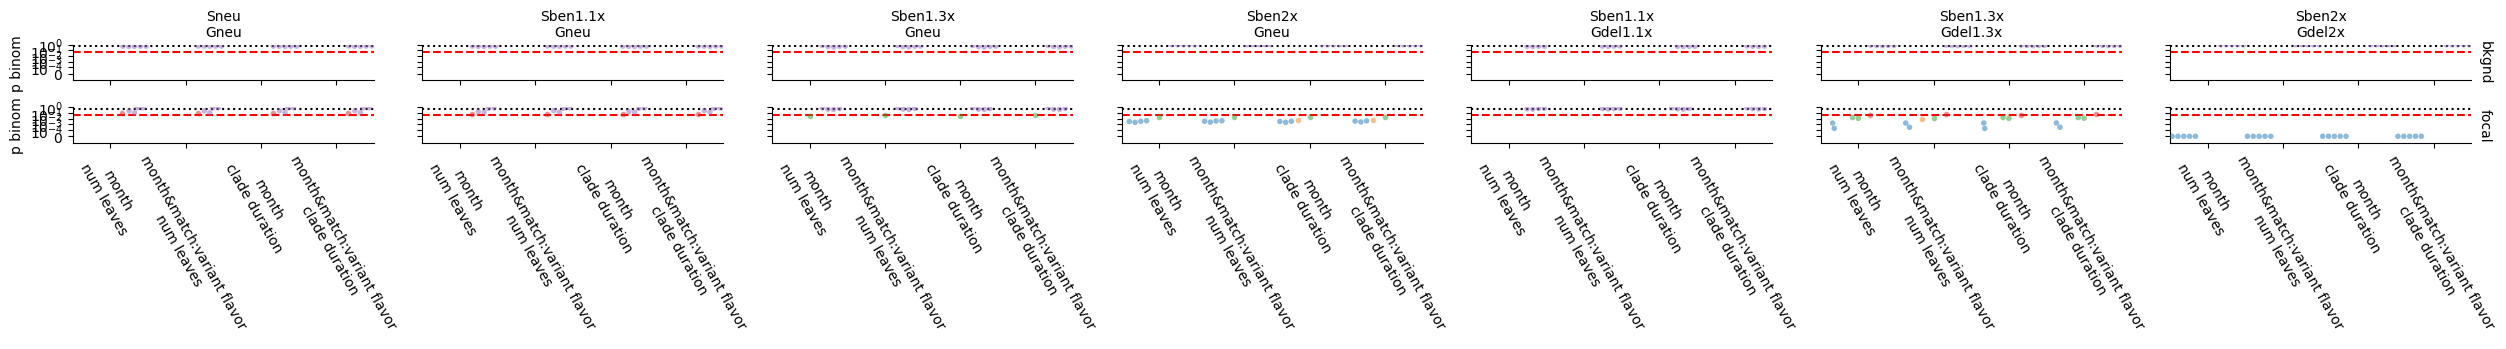

teeplots/2025-05-19-compscreen-multistrain-summary/col=trt-name+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=p-mw+ext=.pdf
teeplots/2025-05-19-compscreen-multistrain-summary/col=trt-name+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=p-mw+ext=.png


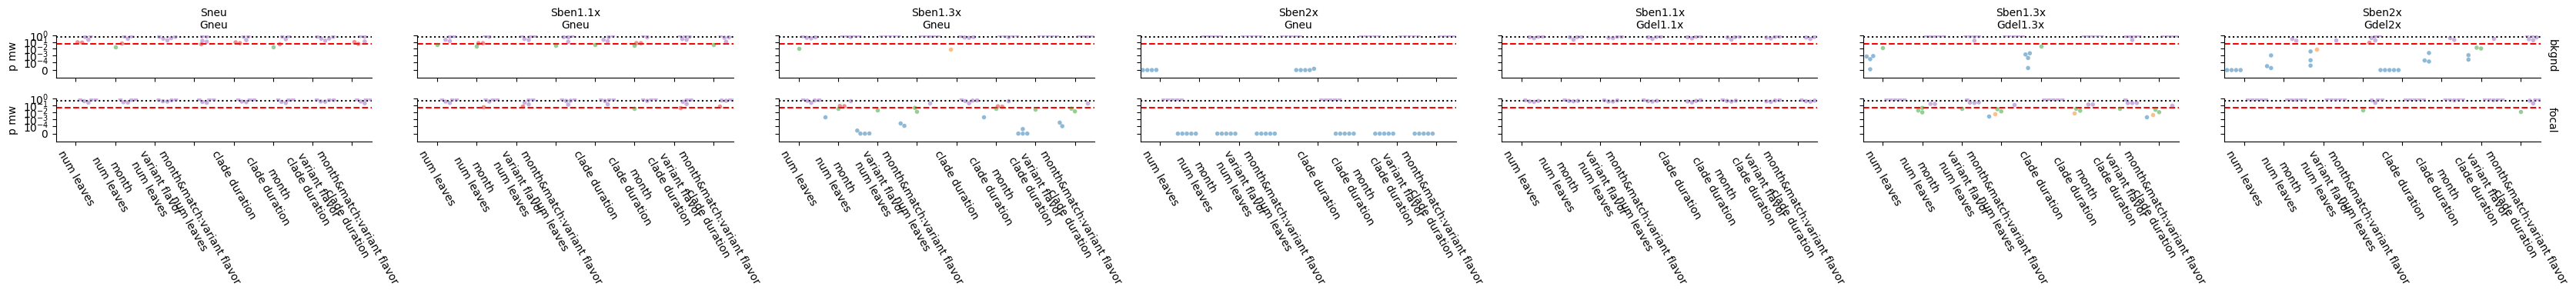

teeplots/2025-05-19-compscreen-multistrain-summary/col=trt-name+comparator=month+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=p-mw+ext=.pdf
teeplots/2025-05-19-compscreen-multistrain-summary/col=trt-name+comparator=month+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=p-mw+ext=.png


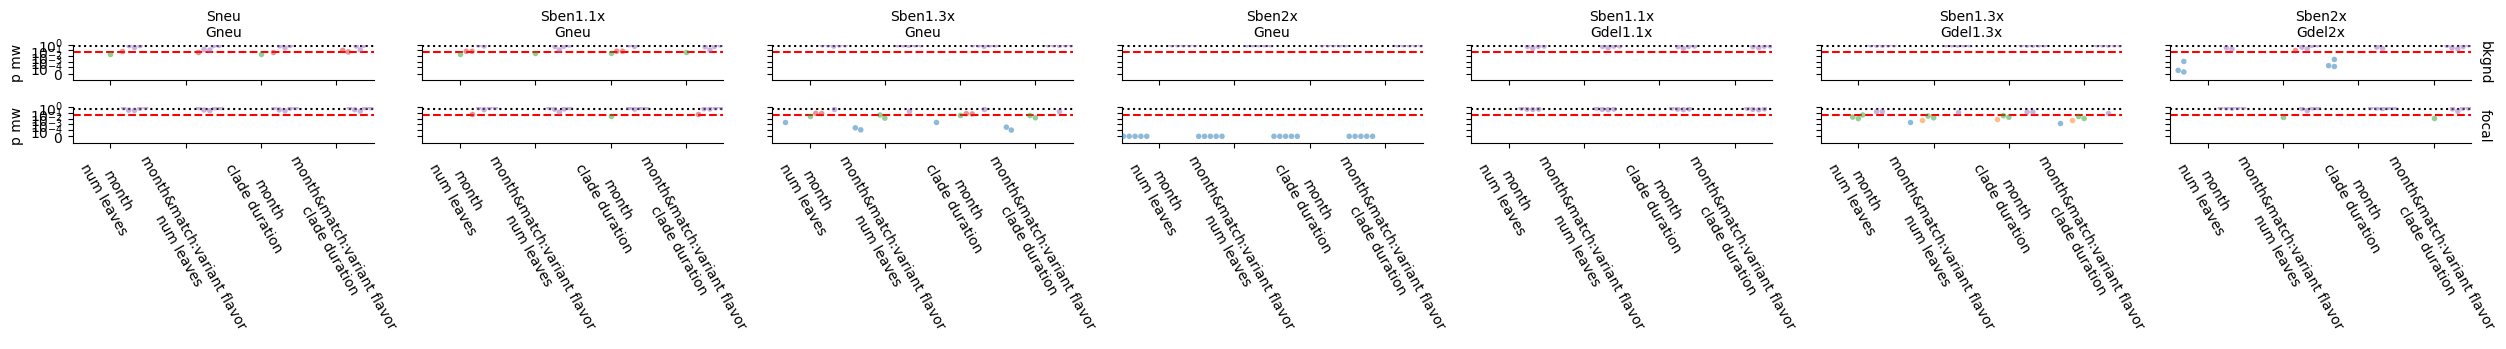

teeplots/2025-05-19-compscreen-multistrain-summary/col=trt-name+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=u-mw+ext=.pdf
teeplots/2025-05-19-compscreen-multistrain-summary/col=trt-name+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=u-mw+ext=.png


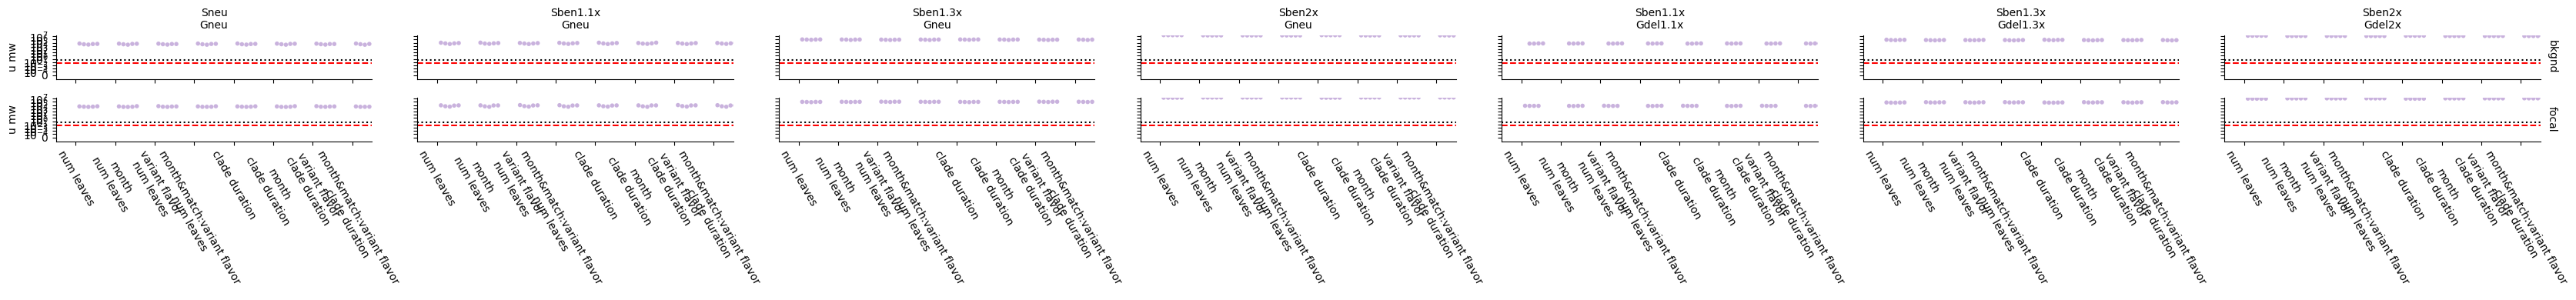

teeplots/2025-05-19-compscreen-multistrain-summary/col=trt-name+comparator=month+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=u-mw+ext=.pdf
teeplots/2025-05-19-compscreen-multistrain-summary/col=trt-name+comparator=month+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=u-mw+ext=.png


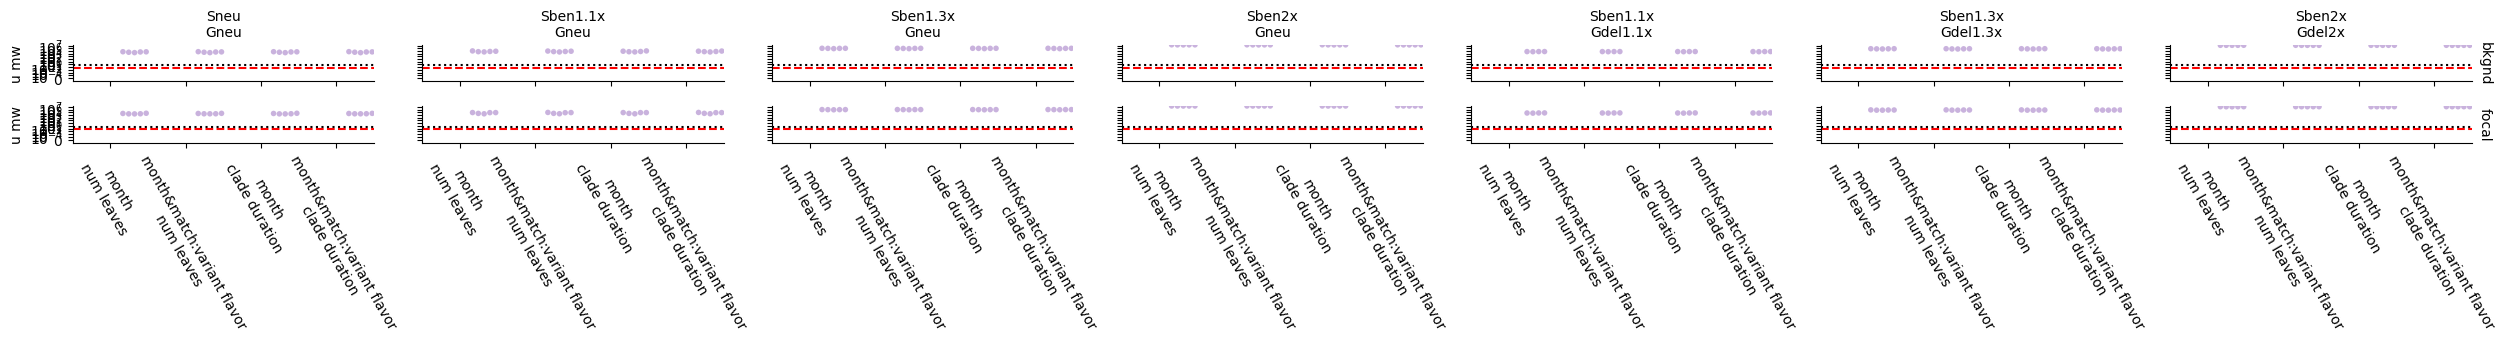

teeplots/2025-05-19-compscreen-multistrain-summary/col=trt-name+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=cliffs-delta+ext=.pdf
teeplots/2025-05-19-compscreen-multistrain-summary/col=trt-name+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=cliffs-delta+ext=.png


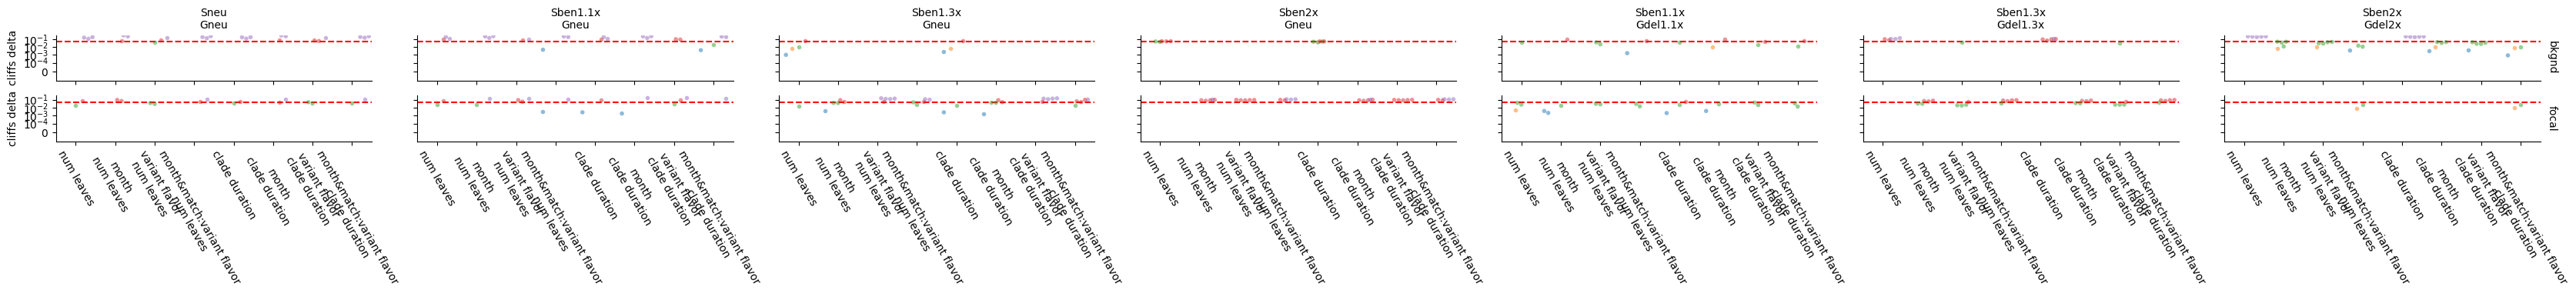

teeplots/2025-05-19-compscreen-multistrain-summary/col=trt-name+comparator=month+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=cliffs-delta+ext=.pdf
teeplots/2025-05-19-compscreen-multistrain-summary/col=trt-name+comparator=month+hue=sig+kind=swarm+row=label+viz=catplot+x=y+y=cliffs-delta+ext=.png


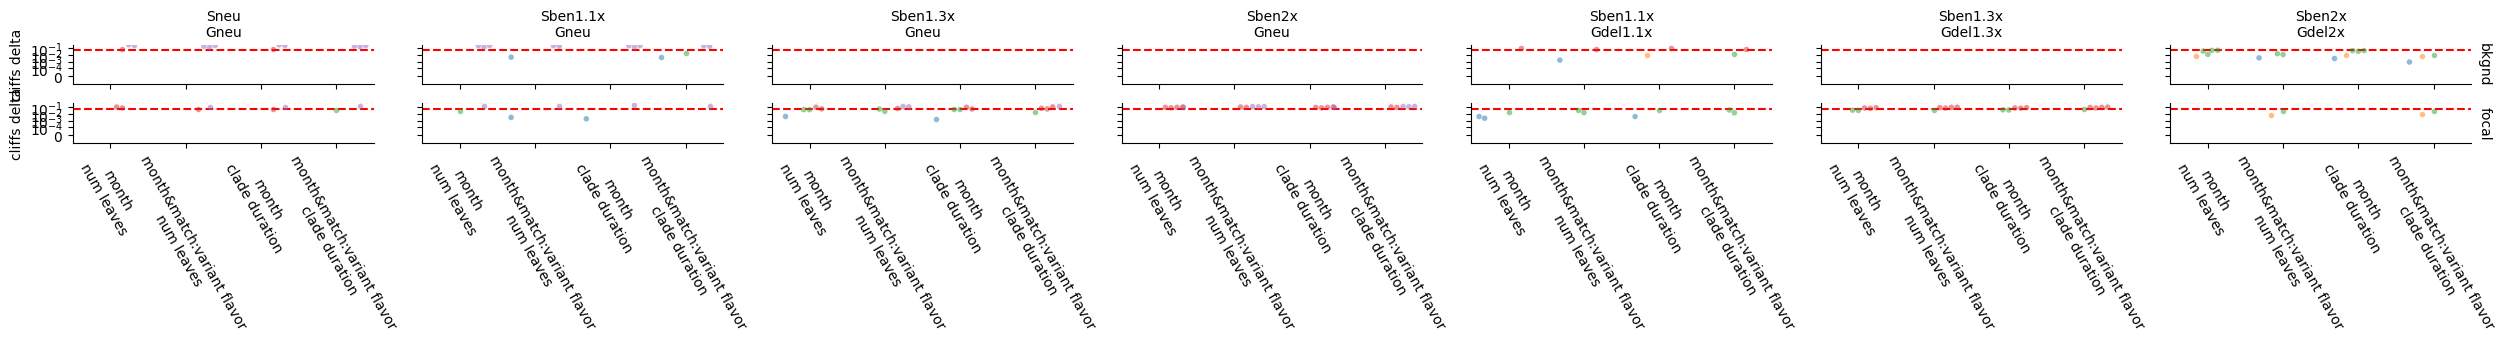

In [10]:
bins = [-np.inf, 0.005, 0.01, 0.05, 0.1, np.inf]
labels = ["<0.005", "<0.01", "<0.05", "<0.1", "ns"]

for y in "p_boot", "p_binom", "p_mw", "u_mw", "cliffs_delta":
    display(HTML(f"<h1>{y=}</h1>"))

    data = results_df[
        (results_df["trt_hsurf_bits"] == 0)
        & (
            results_df["trt_n_downsample"]
            == results_df["trt_n_downsample"].max()
        )
        & (results_df["label"] != "all")
    ].copy()
    data["sig"] = pd.cut(
        data[y],
        bins=bins,
        labels=labels,
        include_lowest=True,
    )
    data["sig"] = data["sig"].cat.set_categories(labels, ordered=True)
    col_order = filter(
        set(data["trt_name_"]).__contains__,
        [
            "Sneu\nGneu",
            "Sben1.1x\nGneu",
            "Sben1.3x\nGneu",
            "Sben2x\nGneu",
            "Sben1.1x\nGdel1.1x",
            "Sben1.3x\nGdel1.3x",
            "Sben2x\nGdel2x",
        ],
    )
    col_order = [*col_order]
    with tp.teed(
        sns.catplot,
        data=data,
        y=y,
        x="y",
        col="trt_name_",
        row="label",
        hue="sig",
        col_order=col_order,
        legend=False,
        kind="swarm",
        dodge=True,
        margin_titles=True,
        alpha=0.5,
        height=2,
        aspect=2.4,
        size=4,
        teeplot_subdir=teeplot_subdir,
    ) as teed:
        teed.set_titles(col_template="{col_name}", row_template="{row_name}")
        for ax in teed.axes.flat:
            ax.set_yscale("symlog", linthresh=0.0001)
            ax.set_ylim(-0.0001, None)
            ax.axhline(0.5, color="black", linestyle=":")
            ax.axhline(0.05, color="red", linestyle="--")
            ax.tick_params(axis="x", rotation=-60)
            ax.set_xlabel("")
            ax.set_ylabel(y.replace("_", " "))

        teed.tight_layout()

    with tp.teed(
        sns.catplot,
        data=data[data["y"].str.startswith("month").values],
        y=y,
        x="y",
        col="trt_name_",
        row="label",
        hue="sig",
        col_order=col_order,
        legend=False,
        kind="swarm",
        dodge=True,
        margin_titles=True,
        alpha=0.5,
        height=1.8,
        aspect=2,
        size=4,
        teeplot_outattrs={"comparator": "month"},
        teeplot_subdir=teeplot_subdir,
    ) as teed:
        teed.set_titles(col_template="{col_name}", row_template="{row_name}")
        for ax in teed.axes.flat:
            ax.set_yscale("symlog", linthresh=0.0001)
            ax.set_ylim(-0.0001, None)
            ax.axhline(0.5, color="black", linestyle=":")
            ax.axhline(0.05, color="red", linestyle="--")
            ax.tick_params(axis="x", rotation=-60)
            ax.set_xlabel("")
            ax.set_ylabel(y.replace("_", " "))

        teed.tight_layout()
